### Reading the data

In [26]:
import os
os.getcwd()
# os.chdir("/home/bardia/graphical-sampling")
# os.chdir("/home/bardia/graphical-sampling/simulations")
# os.chdir('/config/ws/graphical-sampling/simulations')
# os.chdir('/Users/Apc/graphical-sampling/simulations')
# os.chdir('/home/dell/projects/graphical-sampling/simulations')
os.chdir('/home/bardia/projects/graphical-sampling/simulations')

In [27]:
# =========================================================
# CELL 1
# LOAD ALL DESIGNS
# =========================================================

import pickle
from pathlib import Path

# =========================================================
# ROOT
# =========================================================

root = Path("best_designs")

# =========================================================
# STORAGE
# =========================================================

designs = {}

failed_files = []

# =========================================================
# NAME CONVERTER
# =========================================================

def simplify_name(population, stem):

    # -----------------------------------------------------
    # METHOD
    # -----------------------------------------------------

    if stem.startswith("best_design"):

        method = "best"

    elif stem.startswith("initial_design"):

        method = "initial"

    else:

        method = "unknown"

    # =====================================================
    # MEUSE / SWISS
    # =====================================================

    if population in ["meuse", "swiss"]:

        parts = stem.split("_")

        n = parts[-3]

        mode = parts[-1]

        return f"{population}_{method}_{n}_{mode}"

    # =====================================================
    # ROBERTSON POPULATIONS
    # =====================================================

    elif population == "robertson":

        # -------------------------------------------------
        # Population
        # -------------------------------------------------

        if "Aggregated" in stem:

            pop = "aggregated"

        elif "Regular" in stem:

            pop = "regular"

        else:

            pop = "unknown"

        # -------------------------------------------------
        # Sample size
        # -------------------------------------------------

        if "C20" in stem:

            n = "20"

        elif "C50" in stem:

            n = "50"

        else:

            n = "?"

        # -------------------------------------------------
        # Robertson designs are EP
        # -------------------------------------------------

        mode = "ep"

        return f"{pop}_{method}_{n}_{mode}"

    # =====================================================
    # FALLBACK
    # =====================================================

    return f"{population}_{stem}"

# =========================================================
# LOAD DESIGNS
# =========================================================

for pop_folder in root.iterdir():

    if not pop_folder.is_dir():

        continue

    population = pop_folder.name

    for file in pop_folder.glob("*.pkl"):

        try:

            with open(file, "rb") as f:

                design = pickle.load(f)

            short_name = simplify_name(
                population,
                file.stem
            )

            designs[short_name] = design

        except Exception as e:

            failed_files.append(
                (str(file), str(e))
            )

# =========================================================
# SUMMARY
# =========================================================

print("\n================================================")
print("LOADED DESIGNS")
print("================================================\n")

for k in sorted(designs.keys()):

    print(k)

print("\n================================================")
print("TOTAL LOADED")
print("================================================\n")

print(len(designs))

# =========================================================
# FAILED FILES
# =========================================================

if len(failed_files) > 0:

    print("\n================================================")
    print("FAILED FILES")
    print("================================================\n")

    for f, err in failed_files:

        print(f)

        print(err)

        print("-"*60)

# =========================================================
# EXAMPLES
# =========================================================

# designs["meuse_best_5_ep"]

# designs["swiss_initial_100_up"]

# designs["aggregated_best_50_ep"]

# designs["regular_initial_20_ep"]


LOADED DESIGNS

aggregated_best_20_ep
aggregated_best_50_ep
aggregated_initial_20_ep
aggregated_initial_50_ep
meuse_best_10_ep
meuse_best_10_up
meuse_best_20_ep
meuse_best_20_up
meuse_best_5_ep
meuse_best_5_up
meuse_initial_10_ep
meuse_initial_10_up
meuse_initial_20_ep
meuse_initial_20_up
meuse_initial_5_ep
meuse_initial_5_up
regular_best_20_ep
regular_best_50_ep
regular_initial_20_ep
regular_initial_50_ep
swiss_best_100_ep
swiss_best_100_up
swiss_best_150_ep
swiss_best_150_up
swiss_best_50_ep
swiss_best_50_up
swiss_initial_100_ep
swiss_initial_100_up
swiss_initial_150_ep
swiss_initial_150_up
swiss_initial_50_ep
swiss_initial_50_up

TOTAL LOADED

32


In [28]:
# =========================================================
# CELL 2.0
# Robertson Varianbles based on the coordinates
# =========================================================

import numpy as np

def robertson_variables(x1, x2, positive_shift=True):

    corrugated = (
        3 * (x1 + x2)
        +
        np.sin(6 * (x1 + x2))
    )

    peak = (
        (
            3 * (4 - 6*x1)**2
            *
            np.exp(
                -(6*x1 - 3)**2
                -
                (6*x2 - 2)**2
            )
            -
            10
            *
            (
                0.2*(6*x1 - 3)
                -
                (6*x1 - 3)**3
                -
                (6*x2 - 3)**5
            )
            *
            np.exp(
                -(6*x1 - 3)**2
                -
                (6*x2 - 3)**2
            )
            -
            (1/3)
            *
            np.exp(
                -(6*x1 - 2)**2
                -
                (6*x2 - 3)**2
            )
        )
    )

    bird = (
        1/20
        *
        (
            (12*x1 - 12*x2)**2
            +
            np.exp(
                (1 - np.sin(12*x1 - 6))**2
            )
            *
            np.cos(12*x2 - 6)
            +
            np.exp(
                (1 - np.cos(12*x2 - 6))**2
            )
            *
            np.sin(12*x1 - 6)
        )
    )

    if positive_shift:

        peak = peak + 7

        bird = bird + 6

    return {

        "corrugated": corrugated,

        "plane": corrugated,

        "peak": peak,

        "bird": bird,
    }

In [29]:
# =========================================================
# LOAD POPULATIONS
# =========================================================

import os
import pandas as pd
import numpy as np

from package_sampling.utils import inclusion_probabilities

# =========================================================
# FILES
# =========================================================

files = [

    "meuse.csv",

    "swiss.csv",

    "AggregatedPop1000.csv",

    "RegularPop1000.csv"
]

# =========================================================
# POPULATION LOADER
# =========================================================

def popus(n, path="populations/real"):

    dfs = {}

    for f in files:

        full_path = os.path.join(path, f)

        # -------------------------------------------------
        # Check existence
        # -------------------------------------------------

        if not os.path.exists(full_path):

            print(f"Warning: {full_path} not found.")

            continue

        # -------------------------------------------------
        # Read file
        # -------------------------------------------------

        df = pd.read_csv(full_path)

        N_pop = len(df)

        name = f.replace(".csv", "")

        # -------------------------------------------------
        # Equal probabilities
        # -------------------------------------------------

        pik_ep = np.repeat(
            n / N_pop,
            N_pop
        )


        # =================================================
        # ROBERTSON POPULATIONS
        # =================================================

        if f in [

            "AggregatedPop1000.csv",

            "RegularPop1000.csv"
        ]:

            coords = df.to_numpy()

            x1 = coords[:, 0]

            x2 = coords[:, 1]

            vars_robertson = robertson_variables(x1, x2)

            dfs[f"df_{name}"] = pd.DataFrame({

                "coord_x" : x1,

                "coord_y" : x2,

                "pik_ep" : pik_ep,

                "z" : vars_robertson["corrugated"],

                "plane" : vars_robertson["plane"],

                "peak" : vars_robertson["peak"],

                "bird" : vars_robertson["bird"],

                # "corrugated" : vars_robertson["corrugated"],
            })

        # =================================================
        # MEUSE
        # =================================================

        elif f == "meuse.csv":

            coords = df[["x", "y"]].to_numpy()

            # unequal probabilities
            pik_up = inclusion_probabilities(

                df["copper"].to_numpy().copy(),

                n
            )

            dfs[f"df_{name}"] = pd.DataFrame({

                "coord_x" : coords[:, 0],

                "coord_y" : coords[:, 1],

                "pik_ep" : pik_ep,

                "pik_up" : pik_up,

                "z" : df["cadmium"]
            })

        # =================================================
        # SWISS
        # =================================================

        elif f == "swiss.csv":

            coords = df[["x", "y"]].to_numpy()

            AREA = df["AREA"].to_numpy().clip(
                5,
                100
            )

            pik_up = inclusion_probabilities(

                AREA.copy(),

                n
            )

            dfs[f"df_{name}"] = pd.DataFrame({

                "coord_x" : coords[:, 0],

                "coord_y" : coords[:, 1],

                "pik_ep" : pik_ep,

                "pik_up" : pik_up,

                "z" : df["AREA_A"]
            })

    return dfs

# =========================================================
# LOAD MAIN POPULATIONS
# =========================================================

p50 = popus(50)

regular = p50["df_RegularPop1000"]

aggregated = p50["df_AggregatedPop1000"]

meuse = p50["df_meuse"]

swiss = p50["df_swiss"]

# =========================================================
# CHECK
# =========================================================

print("\n================================================")
print("POPULATIONS LOADED")
print("================================================\n")

print("regular:", regular.shape)

print("aggregated:", aggregated.shape)

print("meuse:", meuse.shape)

print("swiss:", swiss.shape)


POPULATIONS LOADED

regular: (1000, 7)
aggregated: (1000, 7)
meuse: (155, 5)
swiss: (959, 5)


In [31]:
# =========================================================
# CELL 4
# BUILD SUMMARY DATAFRAME
# =========================================================

import pandas as pd
import numpy as np

# =========================================================
# STORAGE
# =========================================================

rows = []

# =========================================================
# POPULATION MAPPER
# =========================================================

population_map = {

    "regular" : regular,

    "aggregated" : aggregated,

    "meuse" : meuse,

    "swiss" : swiss
}

# =========================================================
# LOOP OVER DESIGNS
# =========================================================

for key, design in designs.items():

    try:

        # -------------------------------------------------
        # Parse design name
        # -------------------------------------------------

        parts = key.split("_")

        population = parts[0]

        method = parts[1]

        n = int(parts[2])

        mode = parts[3]

        # =================================================
        # SELECT POPULATION
        # =================================================

        if population not in population_map:

            print(f"Skipping unknown population: {key}")

            continue

        df = population_map[population]

        # =================================================
        # VARIABLE
        # =================================================

        z = np.asarray(
            df["z"],
            dtype=float
        )

        N = len(z)

        # =================================================
        # DESIGN VARIANCE
        # =================================================

        design._nht_variance = None

        design.pop._variable = z

        var_design = design.nht_variance

        # =================================================
        # SRS VARIANCE
        # =================================================

        var_pop = np.var(
            z,
            ddof=1
        )

        var_srs = (

            N**2

            *

            (1 - n/N)

            *

            var_pop

            /

            n
        )
        print(key, var_srs)

        # =================================================
        # EFFICIENCY
        # =================================================

        efficiency = var_srs / var_design

        # =================================================
        # INDICES
        # =================================================

        moran_mean, moran_std = design.moran

        vor_mean, vor_std = design.voronoi

        lb_mean, lb_std = design.local_balance

        dd_mean, dd_std = design.density_disparity

        # =================================================
        # SAVE
        # =================================================

        rows.append({

            "Population" : population,

            "Method" : method,

            "n" : n,

            "Mode" : mode,

            # -----------------------------------------
            # Moran
            # -----------------------------------------

            "Mm" : moran_mean,

            "Ms" : moran_std,

            # -----------------------------------------
            # Voronoi
            # -----------------------------------------

            "Vm" : vor_mean,

            "Vs" : vor_std,

            # -----------------------------------------
            # Local Balance
            # -----------------------------------------

            "Lm" : lb_mean,

            "Ls" : lb_std,

            # -----------------------------------------
            # Density Disparity
            # -----------------------------------------

            "Dm" : dd_mean,

            "Ds" : dd_std,

            # -----------------------------------------
            # Variance
            # -----------------------------------------

            # "Variance" : var_design,

            # -----------------------------------------
            # Variance x10^4
            # -----------------------------------------

            "Var_e4" : var_design / 1e4,

            # -----------------------------------------
            # Efficiency
            # -----------------------------------------

            "Eff" : efficiency
        })

    except Exception as e:

        print(f"\nFAILED: {key}")

        print(e)

# =========================================================
# DATAFRAME
# =========================================================

df_summary = pd.DataFrame(rows)

# =========================================================
# SORT
# =========================================================

df_summary = df_summary.sort_values(

    by=[
        "Population",
        "Method",
        "Mode",
        "n"
    ]

).reset_index(drop=True)

# =========================================================
# DISPLAY OPTIONS
# =========================================================

pd.set_option(
    "display.float_format",
    "{:,.3f}".format
)

pd.set_option(
    "display.max_columns",
    None
)

# =========================================================
# DISPLAY
# =========================================================

print("\n================================================")
print("SUMMARY RESULTS")
print("================================================\n")

print(df_summary.to_string(index=False))

# =========================================================
# OPTIONAL SAVE
# =========================================================

# df_summary.to_csv(
#     "results/design_summary.csv",
#     index=False
# )

meuse_initial_10_ep 27906.722597402597
meuse_best_20_up 12991.060519480518
meuse_best_5_ep 57738.046753246745
meuse_initial_5_up 57738.046753246745
meuse_best_10_up 27906.722597402597
meuse_initial_20_up 12991.060519480518
meuse_best_5_up 57738.046753246745
meuse_best_10_ep 27906.722597402597
meuse_initial_20_ep 12991.060519480518
meuse_initial_10_up 27906.722597402597
meuse_best_20_ep 12991.060519480518
meuse_initial_5_ep 57738.046753246745
regular_initial_20_ep 103258.65394659518
regular_best_50_ep 40039.069897659356
aggregated_best_50_ep 39023.32254621473
regular_initial_50_ep 40039.069897659356
aggregated_initial_20_ep 100639.09498760641
aggregated_initial_50_ep 39023.32254621473
regular_best_20_ep 103258.65394659518
aggregated_best_20_ep 100639.09498760641
swiss_best_150_ep 6006231.325248286
swiss_best_150_up 6006231.325248286
swiss_initial_50_up 20245973.824415423
swiss_best_50_up 20245973.824415423
swiss_initial_100_up 9566166.95004007
swiss_initial_150_ep 6006231.325248286
swis

### compare with Blair results:

In [33]:
import pandas as pd

# ============================================================
# TABLE 4
# ============================================================

table4 = pd.DataFrame([
    ["Reg",    "Plane", 4.00, 0.58, 0.30, 0.23, 0.26, 0.25, 0.29],
    ["Reg",    "Peak",  7.02, 3.23, 2.10, 1.28, 2.21, 1.29, 2.41],
    ["Reg",    "Bird",  7.14, 3.02, 2.22, 2.10, 2.46, 1.59, 2.67],

    ["Agg", "Plane", 3.90, 0.37, 0.20, 0.21, 0.16, 0.17, 0.18],
    ["Agg", "Peak",  7.76, 2.26, 1.67, 1.43, 1.65, 0.86, 1.89],
    ["Agg", "Bird",  7.20, 2.56, 2.39, 1.86, 2.21, 1.02, 2.52],
], columns=[
    "Popu (var)", "Func",
    "SRS_v",
    "GRTS_si", "GRTS_NBH",
    "HIP_si", "HIP_SB",
    "LPM_si", "LPM_SB"
])

print(table4[["Popu (var)", "Func",
    "SRS_v",
    "GRTS_si",
    "HIP_si", 
    "LPM_si", ]])

# ============================================================
# TABLE 5
# ============================================================

table5 = pd.DataFrame([
    ["Reg",    "Plane", 0.18, 0.32, 0.06, 0.22, 0.09, 0.24, 0.15, 0.30],
    ["Reg",    "Peak",  1.56, 2.33, 0.57, 1.60, 0.21, 1.26, 0.33, 1.35],
    ["Reg",    "Bird",  1.66, 2.09, 1.03, 1.57, 0.56, 1.22, 0.65, 1.33],

    ["Agg", "Plane", 0.10, 0.15, 0.08, 0.15, 0.10, 0.15, 0.11, 0.15],
    ["Agg", "Peak",  0.94, 1.11, 0.64, 0.87, 0.37, 0.69, 0.44, 0.77],
    ["Agg", "Bird",  1.18, 1.43, 0.99, 1.06, 0.56, 0.97, 0.59, 1.02],
], columns=[
    "Popu (var)", "Func",
    "Random_si", "Random_B",
    "Alpha1_si", "Alpha1_B",
    "Alpha07_si", "Alpha07_B",
    "Alpha0_si", "Alpha0_B"
])

print(table5[["Popu (var)", "Func",
    "Random_si", 
    "Alpha1_si", 
    "Alpha07_si",
    "Alpha0_si"]])

  Popu (var)   Func  SRS_v  GRTS_si  HIP_si  LPM_si
0        Reg  Plane  4.000    0.580   0.230   0.250
1        Reg   Peak  7.020    3.230   1.280   1.290
2        Reg   Bird  7.140    3.020   2.100   1.590
3        Agg  Plane  3.900    0.370   0.210   0.170
4        Agg   Peak  7.760    2.260   1.430   0.860
5        Agg   Bird  7.200    2.560   1.860   1.020
  Popu (var)   Func  Random_si  Alpha1_si  Alpha07_si  Alpha0_si
0        Reg  Plane      0.180      0.060       0.090      0.150
1        Reg   Peak      1.560      0.570       0.210      0.330
2        Reg   Bird      1.660      1.030       0.560      0.650
3        Agg  Plane      0.100      0.080       0.100      0.110
4        Agg   Peak      0.940      0.640       0.370      0.440
5        Agg   Bird      1.180      0.990       0.560      0.590


In [34]:
# =========================================================
# LOAD POPULATIONS
# =========================================================

p50 = popus(50)

regular = p50["df_RegularPop1000"]
aggregated = p50["df_AggregatedPop1000"]

# =========================================================
# LOAD DESIGNS
# =========================================================

initial_regular   = designs["regular_initial_50_ep"]
best_regular      = designs["regular_best_50_ep"]

initial_aggregated = designs["aggregated_initial_50_ep"]
best_aggregated    = designs["aggregated_best_50_ep"]

# =========================================================
# ASSIGN VARIABLES TO POPULATIONS
# =========================================================

# ---------- REGULAR ----------
pop_reg_initial = initial_regular.pop
pop_reg_best    = best_regular.pop

# ---------- AGGREGATED ----------
pop_agg_initial = initial_aggregated.pop
pop_agg_best    = best_aggregated.pop

# =========================================================
# ATTACH VARIABLES
# =========================================================

variables = ["plane", "peak", "bird"]

# =========================================================
# FUNCTION
# =========================================================

# =========================================================
# FUNCTION: EXACT DESIGN VARIANCE FOR A GIVEN VARIABLE
# =========================================================

def design_variance(design, y):

    samples, probs = design.all_samples_and_probs

    pik = design.pop.inclusions

    ht = np.sum(
        y[samples] / pik[samples],
        axis=1
    )

    total = np.sum(y)

    var = np.sum(
        probs * (ht - total)**2
    )

    return var
# =========================================================
# RESULTS
# =========================================================

variables = ["plane", "peak", "bird"]

print("\n================================================")
print("VARIANCES / 10000")
print("================================================\n")

for var in variables:

    y_reg = regular[var].to_numpy()
    y_agg = aggregated[var].to_numpy()

    v_reg_initial = design_variance(initial_regular, y_reg) / 10000
    v_reg_best    = design_variance(best_regular, y_reg) / 10000

    v_agg_initial = design_variance(initial_aggregated, y_agg) / 10000
    v_agg_best    = design_variance(best_aggregated, y_agg) / 10000

    print(f"{var.upper():>10s}")

    print(
        f"Regular     | Initial = {v_reg_initial:.6f}   "
        f"Best = {v_reg_best:.6f}"
    )

    print(
        f"Aggregated  | Initial = {v_agg_initial:.6f}   "
        f"Best = {v_agg_best:.6f}"
    )

    print("-"*60)


VARIANCES / 10000

     PLANE
Regular     | Initial = 2.432802   Best = 0.826365
Aggregated  | Initial = 0.917222   Best = 0.358287
------------------------------------------------------------
      PEAK
Regular     | Initial = 0.347354   Best = 0.204050
Aggregated  | Initial = 0.358247   Best = 0.502676
------------------------------------------------------------
      BIRD
Regular     | Initial = 0.918824   Best = 0.391118
Aggregated  | Initial = 0.568032   Best = 0.771342
------------------------------------------------------------


In [37]:
import pandas as pd

# ============================================================
# ROBERTSON TABLE 4: existing designs, only _si
# ============================================================

table4_si = pd.DataFrame([
    ["Reg", "Plane", 4.00, 0.58, 0.23, 0.25],
    ["Reg", "Peak",  7.02, 3.23, 1.28, 1.29],
    ["Reg", "Bird",  7.14, 3.02, 2.10, 1.59],

    ["Agg", "Plane", 3.90, 0.37, 0.21, 0.17],
    ["Agg", "Peak",  7.76, 2.26, 1.43, 0.86],
    ["Agg", "Bird",  7.20, 2.56, 1.86, 1.02],
], columns=[
    "Popu", "Func",
    "SRS_si",
    "GRTS_si",
    "HIP_si",
    "LPM_si"
])

# ============================================================
# ROBERTSON TABLE 5: only alpha0 and random, only _si
# ============================================================

table5_si = pd.DataFrame([
    ["Reg", "Plane", 0.18, 0.15],
    ["Reg", "Peak",  1.56, 0.33],
    ["Reg", "Bird",  1.66, 0.65],

    ["Agg", "Plane", 0.10, 0.11],
    ["Agg", "Peak",  0.94, 0.44],
    ["Agg", "Bird",  1.18, 0.59],
], columns=[
    "Popu", "Func",
    "OPCrand_si",
    "OPCopt_si"
])

# ============================================================
# MY RESULTS
# ============================================================

mine = pd.DataFrame([
    ["Reg", "Plane", 2.43, 0.82],
    ["Agg", "Plane", 0.91, 0.35],

    ["Reg", "Peak",  0.34, 0.20],
    ["Agg", "Peak",  0.35, 0.50],

    ["Reg", "Bird",  0.91, 0.39],
    ["Agg", "Bird",  0.56, 0.77],
], columns=[
    "Popu", "Func",
    "My_Ini_si",
    "My_Best_si"
])

# ============================================================
# MERGE
# ============================================================

df_compare = (
    table4_si
    .merge(table5_si, on=["Popu", "Func"], how="left")
    .merge(mine, on=["Popu", "Func"], how="left")
)

# ============================================================
# ROUND LIKE PAPER TABLES
# ============================================================

num_cols = df_compare.select_dtypes(include="number").columns

df_compare[num_cols] = df_compare[num_cols].round(2)

# ============================================================
# DISPLAY
# ============================================================

print(df_compare.to_string(index=False))

Popu  Func  SRS_si  GRTS_si  HIP_si  LPM_si  OPCrand_si  OPCopt_si  My_Ini_si  My_Best_si
 Reg Plane   4.000    0.580   0.230   0.250       0.180      0.150      2.430       0.820
 Reg  Peak   7.020    3.230   1.280   1.290       1.560      0.330      0.340       0.200
 Reg  Bird   7.140    3.020   2.100   1.590       1.660      0.650      0.910       0.390
 Agg Plane   3.900    0.370   0.210   0.170       0.100      0.110      0.910       0.350
 Agg  Peak   7.760    2.260   1.430   0.860       0.940      0.440      0.350       0.500
 Agg  Bird   7.200    2.560   1.860   1.020       1.180      0.590      0.560       0.770


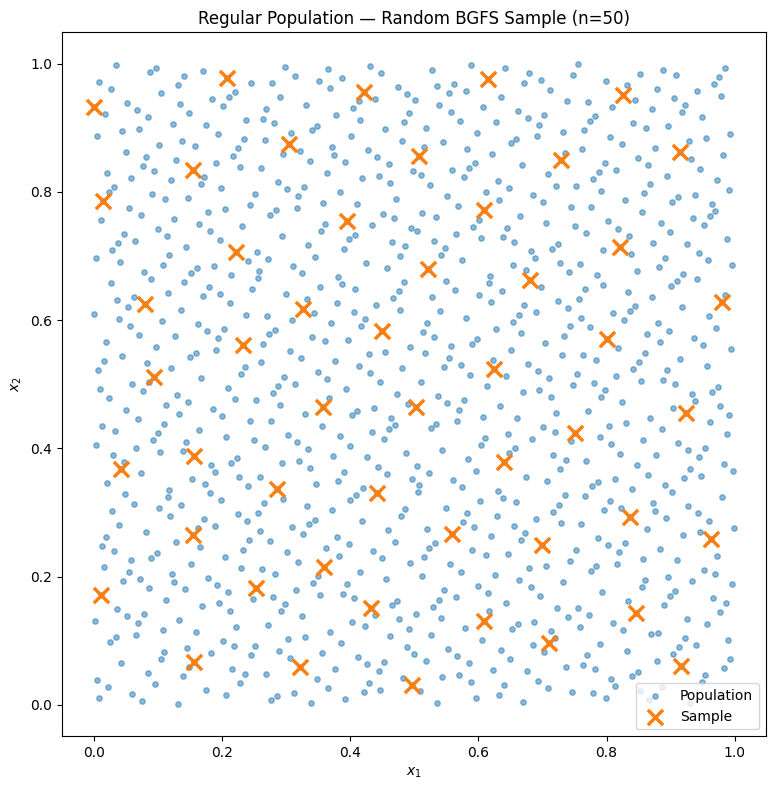

In [35]:
# =========================================================
# CELL 5 (RANDOM SAMPLE EACH RUN)
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# DESIGN
# =========================================================

design = designs["regular_best_50_ep"]

# =========================================================
# POPULATION
# =========================================================

df = regular

coords = df[
    ["coord_x", "coord_y"]
].to_numpy()

# =========================================================
# ALL POSSIBLE SAMPLES
# =========================================================

samples, probs = design.all_samples_and_probs

# =========================================================
# RANDOMLY SELECT ONE SAMPLE
# =========================================================

idx = np.random.choice(

    len(samples),

    p=probs
)

sample = np.asarray(

    samples[idx],

    dtype=int
)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(8, 8))

# ---------------------------------------------------------
# Population
# ---------------------------------------------------------

plt.scatter(

    coords[:, 0],

    coords[:, 1],

    s=15,

    alpha=0.5,

    label="Population"
)

# ---------------------------------------------------------
# Sample
# ---------------------------------------------------------

plt.scatter(

    coords[sample, 0],

    coords[sample, 1],

    s=120,

    marker="x",

    linewidths=2.5,

    label="Sample"
)

# =========================================================
# STYLE
# =========================================================

plt.title(
    f"Regular Population — Random BGFS Sample (n={len(sample)})"
)

plt.xlabel(r"$x_1$")

plt.ylabel(r"$x_2$")

plt.gca().set_aspect("equal")

plt.legend()

plt.tight_layout()

plt.show()